# Распознование рагпулла мемкоинов на децентрализованной бирже Raydium с помощью методов машинного обучения
## Введение.
Быстрое распространение мемкоинов на блокчейн платформах увеличило количество мошеннических схем, в частности, рагпуллов токенов на децентрализированных биржах. Данная работа помогает обнаружить мошенническую монету, которая обесценится в течение часа с ее инициализации на бирже, наблюдая за ее поведением на временном промежутке в 5 минут.  

## Описание проекта. 
В данной работе необходимо определить две целевые переменные: $\displaystyle TVL_t = \sum_{p \in \mathcal{P}} \left( P^{(base)}_{p,t} \cdot Q^{(base)}_{p,t} + P^{(quote)}_{p,t} \cdot Q^{(quote)}_{p,t} \right)$ и $\displaystyle{Idle}_t = \mathbb{I}\left( \sum_{\tau = t-w}^{t} V_\tau = 0 \right)$.  
**TVL (Total Value Locked)** - общая стоимость активов в пуле ликвидности, TVL рагпуллы - самая распространенная схема обмана. В момент вывода средств из пулла ликвидности, TVL снижается на 99%, что эквивалентно обесцениванию монеты. **Idle (бездействие)** - рагпулл, в котором операции с монетой не производятся в течение большого количества времени.

Ключевая метрика будет опираться на **максимальную просадку (MDD - Maximum Drawdown)**, $\displaystyle \mathrm{MDD}_t = \frac{\mathrm{TVL}_t - \max_{\tau \le t} \mathrm{TVL}_\tau}{\max_{\tau \le t} \mathrm{TVL}_\tau}$.  
В итоге, ключевая метрика определяется, как $\displaystyle \mathrm{Rug}_t = \mathbb{I}\left( (\mathrm{MDD}_t < -\theta) \lor (\mathrm{Idle}_t > \Delta t) \right)$ 

## Описание датасета
Данные, хранящие информацию о транзакциях на Raydium и минте новых монет на Solana, получены из индексера соланы (https://web3-engineering.gitbook.io/web3-engineering-docs/overview/solana-indexer) (данные собраны напрямую с блокчейн узлов). 

### Структура сырых данных, которые нам еще предстоит обработать:

|solana_mints|raydium_all_swaps||
|-|-:|-|
| slot| slot | base_pool_before |
| tx_idx| tx_idx | quote_pool_before |
| address | address | base_pool_after |
| signature |signature | quote_pool_after |
| block_time | block_time | serum_market_id |
| - | signing_wallet | raydium_market_id |
| - | direction | provided_gas_fee |
| - | base_coin | provided_gas_limit |
| - | quote_coin | fee | consumed_gas |
| - | base_coin_amount | parent_program |
| - | quote_coin_amount |


In [ ]:
from clickhouse_driver import Client #клиент запущен в отдельном окне
import pandas as pd

swaps_result, swaps_meta = client.execute('SELECT * FROM raydium_all_swaps LIMIT 10', with_column_types=True)
mints_result, mints_meta = client.execute('SELECT * FROM solana_mints LIMIT 10', with_column_types=True)

swaps_columns = [col[0] for col in swaps_meta]
mints_columns = [col[0] for col in mints_meta]

swaps = pd.DataFrame(swaps_result, columns = swaps_columns)
mints = pd.DataFrame(mints_result, columns = mints_columns)

swaps_rows = client.execute('SELECT count() FROM raydium_all_swaps')[0][0]
swaps_columns = len(client.execute('DESCRIBE TABLE raydium_all_swaps'))
print(swaps_rows, 'строк,', swaps_columns, 'столбцов')

mints_rows = client.execute('SELECT count() FROM solana_mints')[0][0]
mints_columns = len(client.execute('DESCRIBE TABLE solana_mints'))
print(mints_rows, 'строк', mints_columns, 'столбцов')


6169756332 строк, 21 столбцов
940117 строк 5 столбцов


In [ ]:
swaps.head()

,block_time,slot,tx_idx,signing_wallet,direction,base_coin,quote_coin,base_coin_amount,quote_coin_amount,base_pool_balance_before,...,base_pool_balance_after,quote_pool_balance_after,signature,serum_market_id,raydium_market_id,provided_gas_fee,provided_gas_limit,fee,consumed_gas,parent_program
0,2024-06-01 09:00:00,269189561,147,3r4FuSYHfMqgYkUVNLStZCLbEoNTJ4YhAG3V4L3XHQSQ,S,DmW16hMwiMV592RkekrBm76Gsb8QTgf17atAycv3xCoi,So11111111111111111111111111111111111111112,296129400707,2345456851,115133042502543,...,115429171903250,914182697414,2gfU7vJj5Hc235eJtcpoLSuEWTW5QGRtG85fJ5nSHg3QpM...,Enj5Rh9sQtFxSCSDgqfdmDfbECaQdL9ZxqXnB6SK2P3t,CUe55zsXgnnz7kR63MoAcjH1DjMDWSDiNq884LoJK6Yk,40000,0,37000,38498,
1,2024-06-01 09:00:00,269189561,147,3r4FuSYHfMqgYkUVNLStZCLbEoNTJ4YhAG3V4L3XHQSQ,S,DmW16hMwiMV592RkekrBm76Gsb8QTgf17atAycv3xCoi,So11111111111111111111111111111111111111112,296129400707,2345456851,115133042502543,...,115429171903250,914182697414,2gfU7vJj5Hc235eJtcpoLSuEWTW5QGRtG85fJ5nSHg3QpM...,Enj5Rh9sQtFxSCSDgqfdmDfbECaQdL9ZxqXnB6SK2P3t,CUe55zsXgnnz7kR63MoAcjH1DjMDWSDiNq884LoJK6Yk,40000,0,37000,38498,
2,2024-06-01 09:00:00,269189561,148,6MtTA2uKg6U3hTouEVksPpyXaiDYmgdSCsdbbj2ywg9E,B,FGf1Us3kqu9AXu2x1yWKfiKE8uSx42ACvRiUrbuAodzq,So11111111111111111111111111111111111111112,274280985391370,3780000000,894297150626148154,...,894022869640756784,12278077625032,4bkvdhpRVJ81ULHVGygJ1VbeHSfWRQ2M566bY28DF9fnP7...,5qa8pbngagYZDVJXpBx9MpFm8YQtCkLSo7smuFtQHMH8,92NvJRnTxkaiHcfRd72B8h1SHyj5ZGtMoeFAQvCdB3vB,25000,600000,20000,38132,
3,2024-06-01 09:00:00,269189561,148,6MtTA2uKg6U3hTouEVksPpyXaiDYmgdSCsdbbj2ywg9E,B,FGf1Us3kqu9AXu2x1yWKfiKE8uSx42ACvRiUrbuAodzq,So11111111111111111111111111111111111111112,274280985391370,3780000000,894297150626148154,...,894022869640756784,12278077625032,4bkvdhpRVJ81ULHVGygJ1VbeHSfWRQ2M566bY28DF9fnP7...,5qa8pbngagYZDVJXpBx9MpFm8YQtCkLSo7smuFtQHMH8,92NvJRnTxkaiHcfRd72B8h1SHyj5ZGtMoeFAQvCdB3vB,25000,600000,20000,38132,
4,2024-06-01 09:00:00,269189561,150,Hmsv4DJDD6fmKjUeQ5NMv9oPUinNbmo8o3Vdaap1tymY,B,6gnzV1nFqLL8Ua7GSFLUU1XYZYv7mt9Uaf2U1fmwDJm,So11111111111111111111111111111111111111112,3080215568964861,687000000,1082837089081773747,...,1079756873512808886,240909956188,3LvaFrFci414xFnrcBrZabpCzxrc2Vst8LxsfgLuqyFhRb...,J8kqSmCru8wNScAi7VctXpWQboonxcqxpQ6CXg6LWPN1,CMQvmYfsxpVq9AAB4tDAFsEknXHzZP4bgF13F9xHJft,20000,200000,9000,38132,


In [ ]:
mints.head()

,slot,tx_idx,address,signature,block_time
0,269189771,173,FTm6y3TUgoUDmBUkhzubeUxFPdeFvkb8dhJ7aFcPvUCZ,2BNat3qJkw5jAaSjVAxYERssja4yMWWpNdLp5fJagNNdjr...,2024-06-01 09:01:28
1,269190039,50,95dvo5G6B3szbCdCdvmCb5D5n6FwXKD1PEEJUFKVETRT,3Zr2xqE68vBHWNRjcvn1xeYGNUR1uimpKWbMBggou3sB9N...,2024-06-01 09:03:22
2,269190288,701,9HYB4nFJBXyLoSJfLtmBBtBoAf6Wc9Vm7U4Pe5dEkov2,4JV7ukPzwBb3Kuh4EVJKF4aa1iTctrb4yLK9k5JYGwUwM7...,2024-06-01 09:05:09
3,269190604,1195,HoBE2Upb4vgBabx4wTSm5utic1CE5F4ovLPfoJzkgrvf,3zZv3iAKZg2R5YysQt85gQNnvVtF7CrT6QRVqFucirq12N...,2024-06-01 09:07:23
4,269190658,14,A6agd7KkHv6AcnMAB1xYHR3LoTG7YRUGYTvPEsdigPfn,4NFE6AVJAT2LZKjHjCSHJokyKCMRcwGBJiuM8BwKkJ5kgR...,2024-06-01 09:07:48


In [ ]:
print(mints.info())
print(swaps.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   slot        10 non-null     int64         
 1   tx_idx      10 non-null     int64         
 2   address     10 non-null     object        
 3   signature   10 non-null     object        
 4   block_time  10 non-null     datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 532.0+ bytes
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   block_time                 10 non-null     datetime64[ns]
 1   slot                       10 non-null     int64         
 2   tx_idx                     10 non-null     int64         
 3   signing_wallet             10 non-null     object        
 4  

## Подборка фичей
Для анализа данных были выбраны следующие признаки:
|Признаки|Описание|
|-|-|
| count_tx | Общее количество транзакций, связанных с токеном. |
| purchase_percentage | Процент транзакций, классифицированных как покупки токена. |
| sale_percentage | Процент транзакций, классифицированных как продажи токена. |
| unique_buyers | Количество уникальных кошельков, купивших токен. |
| unique_sellers | Количество уникальных кошельков, продавших токен. |
| total_sol_value | Общая стоимость транзакций, связанных с токеном, в SOL. |
| sell_sol_value | Общая стоимость продаж токена в SOL. |
| buy_sol_value | Общая стоимость покупок токена в SOL. |
| buy_sell_cnt_ratio | Отношение количества транзакций покупки к количеству транзакций продажи. |
| buy_sell_value_ratio | Отношение объёма покупок в SOL к объёму продаж в SOL. |
| price_change_first_to_3_blocks | Изменение цены токена в течение первых трёх блоков активности. |
| price_change_first_to_last | Изменение цены от первой до последней сделки. |
| buy_price_std | Стандартное отклонение цен покупки. |
| sell_price_std | Стандартное отклонение цен продажи. |
| first_buy_time | Временная метка первой транзакции покупки. |
| first_sell_time | Временная метка первой транзакции продажи. |
| min_pool_info_time | Временная метка самой ранней информации о пуле. |
| max_pool_info_time | Временная метка самой поздней информации о пуле. |
| last_trade_time | Временная метка последней сделки. |
| max_price | Максимальная цена. |
| min_price | Минимальная цена. |
| min_price_after_max | Минимальная цена после максимальной цены. |
| first_price | Цена при первой сделке после минта. |

## Рассчет признаков:
Для подсчета фич опытным путем был выведен таймфрейм в 5 минут. Этого времени будет достаточно для предугадывания скама.

In [16]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot
import requests
from io import StringIO
from datetime import datetime, timedelta
from requests.auth import HTTPBasicAuth
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing

In [14]:
START_DATE = "2024-06-30"
END_DATE   = "2025-06-30"
SAVE_DIR   = "raydium"
os.makedirs(SAVE_DIR, exist_ok=True)

WINDOWS    = [5, 60]
SOL = 'So11111111111111111111111111111111111111112'

In [ ]:
def feature_count(df):
    # print("feature_count called, df shape:", df.shape)
    df.groupby('base_coin')['block_time_los'].agg(['min', 'max'])
    df = df.sort_values(['mint_block_time', 'slot', 'tx_idx'])

    df['is_buy'] = df['direction'] == 'B'
    df['is_sell'] = df['direction'] == 'S'
    df['price'] = df['quote_coin_amount'] / df['base_coin_amount']
    first_price = df.groupby('base_coin')['price'].first()
    
    count_tx = df.groupby('base_coin').size()
    buy_cnt = df[df['is_buy']].groupby('base_coin').size()
    sell_cnt = df[df['is_sell']].groupby('base_coin').size()
    buy_sell_cnt_ratio = buy_cnt / sell_cnt.replace(0, np.nan)
    purchase_percentage = buy_cnt / count_tx
    sale_percentage = sell_cnt / count_tx

    unique_buyers = (df[df['is_buy']].groupby('base_coin')['signing_wallet'].nunique())
    unique_sellers = (df[df['is_sell']].groupby('base_coin')['signing_wallet'].nunique())
    total_sol_value = df.groupby('base_coin')['quote_coin_amount'].sum()
    buy_sol_value = (df[df['is_buy']].groupby('base_coin')['quote_coin_amount'].sum())
    sell_sol_value = (df[df['is_sell']].groupby('base_coin')['quote_coin_amount'].sum())
    buy_sell_value_ratio = buy_sol_value / sell_sol_value.replace(0, np.nan)

    def price_change_first_to_3(g):
        if len(g) < 3:
            return np.nan
        p0 = g.iloc[0]['price']
        p3 = g.iloc[2]['price']
        return (p3 - p0) / p0
    price_change_first_to_3_blocks = (df.groupby('base_coin').apply(price_change_first_to_3))
    def price_change_first_to_last(g):
        p0 = g.iloc[0]['price']
        pL = g.iloc[-1]['price']
        return (pL - p0) / p0
    price_change_first_to_last = (df.groupby('base_coin').apply(price_change_first_to_last))

    buy_price_std = (df[df['is_buy']].groupby('base_coin')['price'].std())
    sell_price_std = (df[df['is_sell']].groupby('base_coin')['price'].std())

    first_buy_datetime = (df[df['is_buy']].groupby('base_coin')['block_time_los'].min())
    first_buy_time = (first_buy_datetime - df.groupby('base_coin')['mint_block_time'].first()).dt.total_seconds()
    first_sell_datetime = (df[df['is_sell']].groupby('base_coin')['block_time_los'].min())
    first_sell_time = (first_sell_datetime - df.groupby('base_coin')['mint_block_time'].first()).dt.total_seconds()
    
    max_price = df.groupby('base_coin')['price'].max()
    min_price = df.groupby('base_coin')['price'].min()

    min_pool_info_datetime = (
        df[df['is_sell']]
        .sort_values(
            ['quote_pool_balance_after', 'block_time_los'], ascending=[True, True] 
        )
        .groupby('base_coin')['block_time_los']
        .first()
    )
    min_pool_info_time = (min_pool_info_datetime - df.groupby('base_coin')['mint_block_time'].first()).dt.total_seconds()

    max_pool_info_datetime = (
        df[df['is_buy']]   
        .sort_values(
            ['quote_pool_balance_after', 'block_time_los'], ascending=[False, True]
        )
        .groupby('base_coin')['block_time_los']
        .first()                                   
    )
    max_pool_info_time = (max_pool_info_datetime - df.groupby('base_coin')['mint_block_time'].first()).dt.total_seconds()

    last_trade_datetime = (df.loc[
        lambda x: x['is_buy'] | x['is_sell']] 
        .sort_values('block_time_los')
        .groupby('base_coin')['block_time_los']
        .last())

    last_trade_time = (last_trade_datetime - df.groupby('base_coin')['mint_block_time'].first()).dt.total_seconds()

    def get_min_price_after_max(group):
        if len(group) == 0:
            return np.nan    
        max_price_idx = group['price'].idxmax()    
        data_after_max = group[group.index > max_price_idx]    
        if len(data_after_max) == 0:
            return np.nan    
        return data_after_max['price'].min()
    min_price_after_max = df.groupby('base_coin').apply(get_min_price_after_max)

    def get_price_sequence(group):
        price_seq = group['price'].tolist()
        return price_seq
    

    features = {
    'count_tx': count_tx,
    'purchase_percentage': purchase_percentage,
    'sale_percentage': sale_percentage,
    'unique_buyers': unique_buyers,
    'unique_sellers': unique_sellers,
    'total_sol_value': total_sol_value,
    'sell_sol_value': sell_sol_value,
    'buy_sol_value': buy_sol_value,
    'buy_sell_cnt_ratio': buy_sell_cnt_ratio,
    'buy_sell_value_ratio': buy_sell_value_ratio,
    'price_change_first_to_3_blocks': price_change_first_to_3_blocks,
    'price_change_first_to_last': price_change_first_to_last,
    'buy_price_std': buy_price_std,
    'sell_price_std': sell_price_std,
    'first_buy_time': first_buy_time,
    'first_sell_time': first_sell_time,
    'max_price': max_price,
    'min_price': min_price,
    'min_pool_info_time': min_pool_info_time,
    'max_pool_info_time': max_pool_info_time,
    'last_trade_time': last_trade_time,
    'min_price_after_max': min_price_after_max,
    'first_price': first_price
    }
    features = pd.DataFrame(features)
    raydium_features = features.reset_index()

    return raydium_features

In [ ]:
def run_window_feature(df, minutes, save_file):

    if os.path.exists(save_file):
        return f"{minutes}min skip"

    df = df.copy()
    df[f'mint_after_{minutes}min'] = df['mint_block_time'] + pd.Timedelta(minutes=minutes)

    df_win = df[
        (df['block_time_los'] >= df['mint_block_time']) &
        (df['block_time_los'] <= df[f'mint_after_{minutes}min'])
    ].copy()

    if len(df_win) == 0:
        return f"{minutes}min no data"

    df_win = (
        df_win
        .sort_values('quote_coin_amount', ascending=False)
        .drop_duplicates(subset=['signature', 'base_coin'], keep='first')
    )

    df_win = df_win[
        (df_win['base_coin_amount'] != 0) &
        (df_win['quote_coin_amount'] != 0)
    ]

    df_win = df_win[df_win['quote_pool_balance_after']!=0]

    if len(df_win) == 0:
        return f"{minutes}min empty"

    features = feature_count(df_win)
    features.to_csv(save_file, index=False)

    return f"{minutes}min done"

In [ ]:
def main():

    cpu_n = max(1, multiprocessing.cpu_count() - 1)
    print(f"Using {cpu_n} CPU cores")

    current = datetime.strptime(START_DATE, "%Y-%m-%d")
    end     = datetime.strptime(END_DATE, "%Y-%m-%d")

    while current <= end:

        day_str = current.strftime("%Y-%m-%d")
        print(f"\n====== Running {day_str} ======")

        next_day = (current + timedelta(days=1)).strftime("%Y-%m-%d")

        # 1. чтение свопов
        query_swaps = f"""
            SELECT DISTINCT
                slot, tx_idx, signing_wallet, signature,
                direction, base_coin, quote_coin,
                base_coin_amount, quote_coin_amount,
                base_pool_balance_before, quote_pool_balance_before,
                base_pool_balance_after, quote_pool_balance_after,
                toTimeZone(block_time, 'America/Los_Angeles') as block_time_los
            FROM research.raydium_all_swaps
            WHERE block_time >= '{day_str} 00:00:00'
            AND block_time < '{next_day} 01:00:00'
        """

        response = requests.post(
            'http://localhost:8123',
            auth=HTTPBasicAuth('researcher', 'slkgjnsfsfefnsseof23452fawfd'),
            data=query_swaps,
            params={'default_format': 'CSVWithNames'}
        )

        swaps = pd.read_csv(StringIO(response.text))
        if len(swaps) == 0:
            print("No swaps.")
            current += timedelta(days=1)
            continue

        swaps['block_time_los'] = pd.to_datetime(swaps['block_time_los'])

        part1 = swaps[swaps['base_coin'] == SOL].copy()
        part1.columns = [
            'slot','tx_idx','signing_wallet','signature','direction0',
            'quote_coin','base_coin','quote_coin_amount','base_coin_amount',
            'quote_pool_balance_before','base_pool_balance_before',
            'quote_pool_balance_after','base_pool_balance_after','block_time_los'
        ]
        part1['direction'] = part1['direction0'].replace({'B': 'S', 'S': 'B'})
        part1 = part1.drop(['direction0'], axis=1)

        part2 = swaps[swaps['quote_coin'] == SOL].copy()
        swaps = pd.concat([part1, part2], ignore_index=True, sort=False)

        # 2. чтение минтов
        query_mints = f"""
            SELECT DISTINCT
                slot AS mint_slot, tx_idx AS mint_tx_idx,
                address AS mint, signature AS mint_signature,
                toTimeZone(block_time, 'America/Los_Angeles') as mint_block_time
            FROM research.solana_mints
            WHERE block_time >= '{day_str} 00:00:00'
            AND block_time < '{next_day} 00:00:00'
        """

        response = requests.post(
            'http://localhost:8123',
            auth=HTTPBasicAuth('researcher', 'slkgjnsfsfefnsseof23452fawfd'),
            data=query_mints,
            params={'default_format': 'CSVWithNames'}
        )

        mints = pd.read_csv(StringIO(response.text))
        if len(mints) == 0:
            print("No mints.")
            current += timedelta(days=1)
            continue

        mints['mint_block_time'] = pd.to_datetime(mints['mint_block_time'])

        # 3. слияние
        df = swaps.merge(
            mints[['mint','mint_block_time','mint_slot','mint_tx_idx']],
            left_on='base_coin',
            right_on='mint',
            how='inner'
        )

        if len(df) == 0:
            print("No merged data.")
            current += timedelta(days=1)
            continue

        # 4. Параллельная обработка
        futures = []

        with ProcessPoolExecutor(max_workers=cpu_n) as executor:

            for w in WINDOWS:
                save_file = f"{SAVE_DIR}/features_{w}min_{day_str}.csv"
                futures.append(
                    executor.submit(run_window_feature, df, w, save_file)
                )

            for f in as_completed(futures):
                print(f.result())

        current += timedelta(days=1)

    print("\n====== ALL DONE ======")


if __name__ == "__main__":
    main()



## Анализ признаков

In [12]:
import glob
import joblib
import re

In [15]:
def load_all_features(folder, pattern="*.csv"):

    files = sorted(glob.glob(os.path.join(folder, pattern)))
    print(f"Found {len(files)} files")

    dfs = []
    for f in files:
        try:
            df = pd.read_csv(f)
            df["source_file"] = os.path.basename(f)
            dfs.append(df)
        except Exception as e:
            print(f"Skip {f}: {e}")

    if len(dfs) == 0:
        return pd.DataFrame()
    full_df = pd.concat(dfs, ignore_index=True)
    print("Loaded shape:", full_df.shape)

    return full_df

raydium_feature_60min = load_all_features("raydium_60min")
raydium_feature_5min = load_all_features("raydium_5min")

Found 366 files
Loaded shape: (132884, 25)
Found 365 files
Loaded shape: (78168, 25)


### Общая информация(структура таблиц, количество транзакций средние значения фичей)

In [24]:
raydium_feature_60min.head()

,base_coin,count_tx,purchase_percentage,sale_percentage,unique_buyers,unique_sellers,total_sol_value,sell_sol_value,buy_sol_value,buy_sell_cnt_ratio,...,first_buy_time,first_sell_time,max_price,min_price,min_pool_info_time,max_pool_info_time,last_trade_time,min_price_after_max,first_price,source_file
0,12uy1qYW5FPCSbQ2uDy8BxdvvqpMybeJSAB1FpfvEK3g,385,0.662338,0.337662,234,115.0,1.049798e+12,8.996273e+11,1.501705e+11,1.961538,...,128.0,130.0,8.726414e-05,2.956981e-11,1779.0,743.0,3443.0,2.956981e-11,7.526597e-05,features_60min_2024-06-30.csv
1,142RcxHH2xr9TDCU6qqLttMTSTwxTSYuN6rBf5xDbZsL,424,0.334906,0.665094,133,102.0,1.570428e+11,7.451307e+10,8.252969e+10,0.503546,...,2.0,11.0,7.142347e+00,1.143324e-10,485.0,267.0,485.0,1.143324e-10,2.606517e-04,features_60min_2024-06-30.csv
2,21xj5DKRc7WoQhuDVKHXYPTLLHBMzT3ZUawyx2KJfQs5,1166,0.115780,0.884220,111,85.0,8.892854e+09,2.495307e+08,8.643323e+09,0.130941,...,100.0,101.0,6.110644e-07,6.283203e-11,2099.0,264.0,2220.0,6.283203e-11,8.558224e-08,features_60min_2024-06-30.csv
3,22HcBQR8qk9X4M8g2RjFsdyHgetM5xyWcae9ftdBFwdk,9569,0.425436,0.574564,322,301.0,6.005281e+12,3.013442e+12,2.991839e+12,0.740451,...,133.0,142.0,1.674636e-02,1.970318e-13,3093.0,2417.0,3430.0,1.970318e-13,1.844511e-04,features_60min_2024-06-30.csv
4,23oWcjTMH1YQ2vujERJvKnhjTnjLTcDDZkPPvFfGSnSd,285,0.428070,0.571930,115,71.0,8.792862e+08,1.457862e+08,7.335000e+08,0.748466,...,52.0,59.0,2.429649e-01,8.618713e-11,287.0,172.0,2037.0,8.618713e-11,8.019493e-06,features_60min_2024-06-30.csv


In [3]:
raydium_total_tx = raydium_feature_60min["count_tx"].sum()
raydium_total_tx

714581954

In [4]:
def basic_summary(df, name):
    summary = {}

    summary["total_tx"] = df["count_tx"].sum()
    summary["avg_tx_per_window"] = df["count_tx"].mean()
    summary["median_tx"] = df["count_tx"].median()

    summary["total_volume"] = df["total_sol_value"].sum()
    summary["avg_volume"] = df["total_sol_value"].mean()

    summary["avg_buyers"] = df["unique_buyers"].mean()
    summary["avg_sellers"] = df["unique_sellers"].mean()

    summary["avg_buy_ratio"] = df["purchase_percentage"].mean()
    summary["avg_sell_ratio"] = df["sale_percentage"].mean()

    summary["avg_price_change"] = df["price_change_first_to_last"].mean()

    summary["avg_buy_std"] = df["buy_price_std"].mean()
    summary["avg_sell_std"] = df["sell_price_std"].mean()

    summary["avg_last_trade"] = df["last_trade_time"].mean()

    return pd.Series(summary, name=name)

raydium_summary_60 = basic_summary(raydium_feature_60min, "Raydium_60min")
raydium_summary_60

total_tx             7.145820e+08
avg_tx_per_window    5.377487e+03
median_tx            3.188000e+03
total_volume         3.338943e+17
avg_volume           2.512675e+12
avg_buyers           4.411335e+02
avg_sellers          3.013141e+02
avg_buy_ratio        5.669828e-01
avg_sell_ratio       4.334739e-01
avg_price_change     1.233104e+10
avg_buy_std          7.400219e+04
avg_sell_std         4.367825e+04
avg_last_trade       2.896958e+03
Name: Raydium_60min, dtype: float64

## Процент рагпуллов за указанный промежуток времени по TVL признаку и по Idle(бездействию)

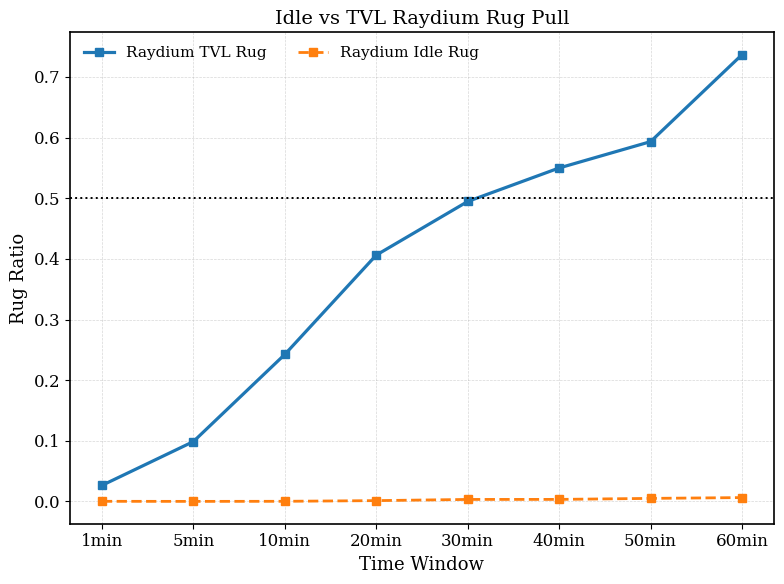

In [23]:
import matplotlib.pyplot as plt

time_order = ["1min","5min","10min","20min","30min","40min","50min","60min"]
pattern = re.compile(r"features_(\d+min)_(\d{4}-\d{2}-\d{2})")

# Rug: TVL
def pumpfun_tvl_rug_ratio(df):
    df["tvl"] = df["min_price_after_max"] / df["max_price"]
    df["is_rug"] = df["tvl"] < 0.01
    return df["is_rug"].mean()

def raydium_tvl_rug_ratio(df):
    df["tvl1"] = df["min_price_after_max"] / df["max_price"]
    df["is_rug"] = df["tvl1"] < 0.01
    return df["is_rug"].mean()

# Rug: Idle
time_to_seconds = {
    "1min": 60,
    "5min": 5*60,
    "10min": 10*60,
    "20min": 20*60,
    "30min": 30*60,
    "40min": 40*60,
    "50min": 50*60,
    "60min": 60*60
}

def raydium_idle_rug_ratio(df, T_end):
    df = df.copy()
    df["idle_duration"] = (T_end - df["last_trade_time"]).clip(lower=0)
    df["is_idle_rug"] = df["idle_duration"] > (T_end * 0.8)
    return df["is_idle_rug"].mean()


def raydium_compute_from_folder(folder):

    merged = {t: [] for t in time_order}
    for fname in os.listdir(folder):
        m = pattern.search(fname)
        if not m:
            continue
        window = m.group(1)
        if window not in time_order:
            continue
        path = os.path.join(folder, fname)
        df = pd.read_csv(path)
        merged[window].append(df)

    rug_all  = []
    idle_all = []
    for t in time_order:
        if not merged[t]:
            rug_all.append(np.nan)
            idle_all.append(np.nan)
            continue

        df_all = pd.concat(merged[t], ignore_index=True)
        # TVL Rug
        rug_all.append(raydium_tvl_rug_ratio(df_all))
        # Idle Rug
        T_end = time_to_seconds[t]
        idle_all.append(raydium_idle_rug_ratio(df_all, T_end))
    return np.array(rug_all), np.array(idle_all)

ray_collapse, ray_idle  = raydium_compute_from_folder('raydium')

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "axes.linewidth": 1.2
})

x_numeric = np.arange(len(time_order))

plt.figure(figsize=(8,6))

plt.plot(x_numeric, ray_collapse, linewidth=2.3, marker='s',
         label="Raydium TVL Rug")

plt.plot(x_numeric, ray_idle, linewidth=2.0, linestyle='--', marker='s',
         label="Raydium Idle Rug")

plt.axhline(0.5, linestyle=":", linewidth=1.4, color="black")

plt.xticks(x_numeric, time_order)
plt.xlabel("Time Window")
plt.ylabel("Rug Ratio")
plt.title("Idle vs TVL Raydium Rug Pull")

plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
plt.legend(frameon=False, ncol=2)

plt.tight_layout()
plt.show()

Как можно заметить, количество рагпуллов, вызванных бездействием мало по отношению к TVL. Однако для более надежного результата не будем опускать данную метрику:

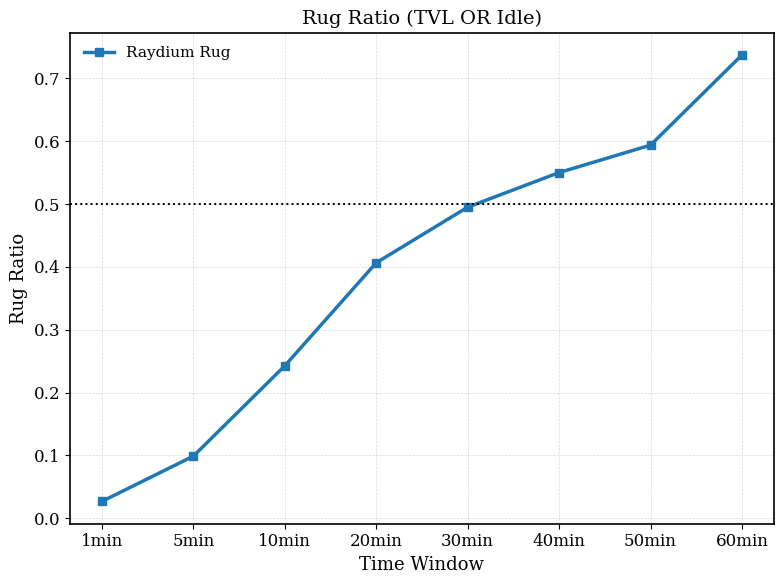

In [28]:
def raydium_final_rug_ratio(df, T_end):
    df = df.copy()

    # TVL Rug
    df["tvl"] = df["min_price_after_max"] / df["max_price"]
    df["tvl_rug"] = df["tvl"] < 0.01 #
    # Idle Rug
    df["idle_duration"] = (T_end - df["last_trade_time"]).clip(lower=0)
    df["idle_rug"] = df["idle_duration"] > (T_end * 0.8) #
    # Final Rug
    df["final_rug"] = df["tvl_rug"] | df["idle_rug"]
    return df["final_rug"].mean()


def raydium_compute_from_folder(folder):

    merged = {t: [] for t in time_order}

    for fname in os.listdir(folder):
        m = pattern.search(fname)
        if not m:
            continue

        window = m.group(1)
        if window not in time_order:
            continue

        df = pd.read_csv(os.path.join(folder, fname))
        merged[window].append(df)

    final_rug = []

    for t in time_order:
        if not merged[t]:
            final_rug.append(np.nan)
            continue

        df_all = pd.concat(merged[t], ignore_index=True)
        T_end = time_to_seconds[t]

        final_rug.append(
            raydium_final_rug_ratio(df_all, T_end)
        )

    return np.array(final_rug)

ray_final = raydium_compute_from_folder('raydium')

x_numeric = np.arange(len(time_order))

plt.figure(figsize=(8, 6))

plt.plot(x_numeric, ray_final, linewidth=2.5, marker='s',
         label="Raydium Rug")

plt.axhline(0.5, linestyle=":", linewidth=1.4, color="black")

plt.xticks(x_numeric, time_order)
plt.xlabel("Time Window")
plt.ylabel("Rug Ratio")
plt.title("Rug Ratio (TVL OR Idle)")

plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

## Маркировка монет (Rug/Not Rug)

In [31]:
def raydium_build_rug_60min_labels(df1,
                     tvl_threshold= 0.01,
                     idle_threshold_sec= 2880):

    df = df1.copy()

    # TVL Rug 
    df["tvl"] = df["min_price_after_max"] / df["max_price"]
    df["rug_tvl"] = (df["tvl"] < tvl_threshold).astype(int)
    # Idle Rug (60*60)
    df["idle_duration"] = 3600 - df["last_trade_time"]
    df["idle_duration"] = df["idle_duration"].clip(lower=0)
    df["rug_idle"] = (df["idle_duration"] > idle_threshold_sec).astype(int)
    # Any Rug
    df["rug"] = ((df["rug_tvl"] == 1) | (df["rug_idle"] == 1)).astype(int)

    return df[
        [
            "base_coin",
            "rug_tvl",
            "rug_idle",
            "rug"
        ]
    ]
def raydium_build_rug_5min_labels(df1,
                     tvl_threshold= 0.01,
                     idle_threshold_sec= 240):

    df = df1.copy()

    # TVL Rug 
    df["tvl"] = df["min_price_after_max"] / df["max_price"]
    df["5min_rug_tvl"] = (df["tvl"] < tvl_threshold).astype(int)
    # Idle Rug (5*60)
    df["idle_duration"] = 300 - df["last_trade_time"]
    df["idle_duration"] = df["idle_duration"].clip(lower=0)
    df["5min_rug_idle"] = (df["idle_duration"] > idle_threshold_sec).astype(int)
    # Any Rug
    df["5min_rug"] = ((df["5min_rug_tvl"] == 1) | (df["5min_rug_idle"] == 1)).astype(int)

    return df[
        [
            "base_coin",
            "5min_rug_tvl",
            "5min_rug_idle",
            "5min_rug"
        ]
    ]

rug_labeled_60min_raydium = raydium_build_rug_60min_labels(raydium_feature_60min)
rug_labeled_5min_raydium = raydium_build_rug_5min_labels(raydium_feature_5min)

train_raydium = raydium_feature_5min.merge(
    rug_labeled_60min_raydium,
    on="base_coin",
    how="inner"
)
train_raydium = train_raydium.merge(
    rug_labeled_5min_raydium,
    on="base_coin",
    how="inner"
)
train_raydium = train_raydium.drop(['base_coin','source_file'], axis=1)

train_raydium.head()


,count_tx,purchase_percentage,sale_percentage,unique_buyers,unique_sellers,total_sol_value,sell_sol_value,buy_sol_value,buy_sell_cnt_ratio,buy_sell_value_ratio,...,max_pool_info_time,last_trade_time,min_price_after_max,first_price,rug_tvl,rug_idle,rug,5min_rug_tvl,5min_rug_idle,5min_rug
0,128,0.671875,0.328125,84.0,42.0,1.052738e+10,1.336328e+09,9.191050e+09,2.047619,6.877839,...,290.0,290.0,NaN,7.526597e-05,1,0,1,0,0,0
1,179,0.575419,0.424581,102.0,75.0,1.162555e+11,5.478102e+10,6.147447e+10,1.355263,1.122186,...,267.0,295.0,2.661137e-04,2.606517e-04,1,1,1,0,0,0
2,295,0.423729,0.576271,106.0,77.0,8.891114e+09,2.487005e+08,8.642413e+09,0.735294,34.750286,...,264.0,300.0,2.386918e-10,8.558224e-08,1,0,1,1,0,1
3,572,0.597902,0.402098,212.0,129.0,3.072257e+11,1.317137e+11,1.755120e+11,1.486957,1.332527,...,252.0,300.0,1.313449e-03,1.844511e-04,1,0,1,0,0,0
4,212,0.561321,0.438679,112.0,66.0,8.790613e+08,1.456713e+08,7.333900e+08,1.279570,5.034555,...,172.0,300.0,8.618713e-11,8.019493e-06,1,0,1,1,0,1


In [26]:
#
#
#
#
#
#
#
#
#
#
#
#

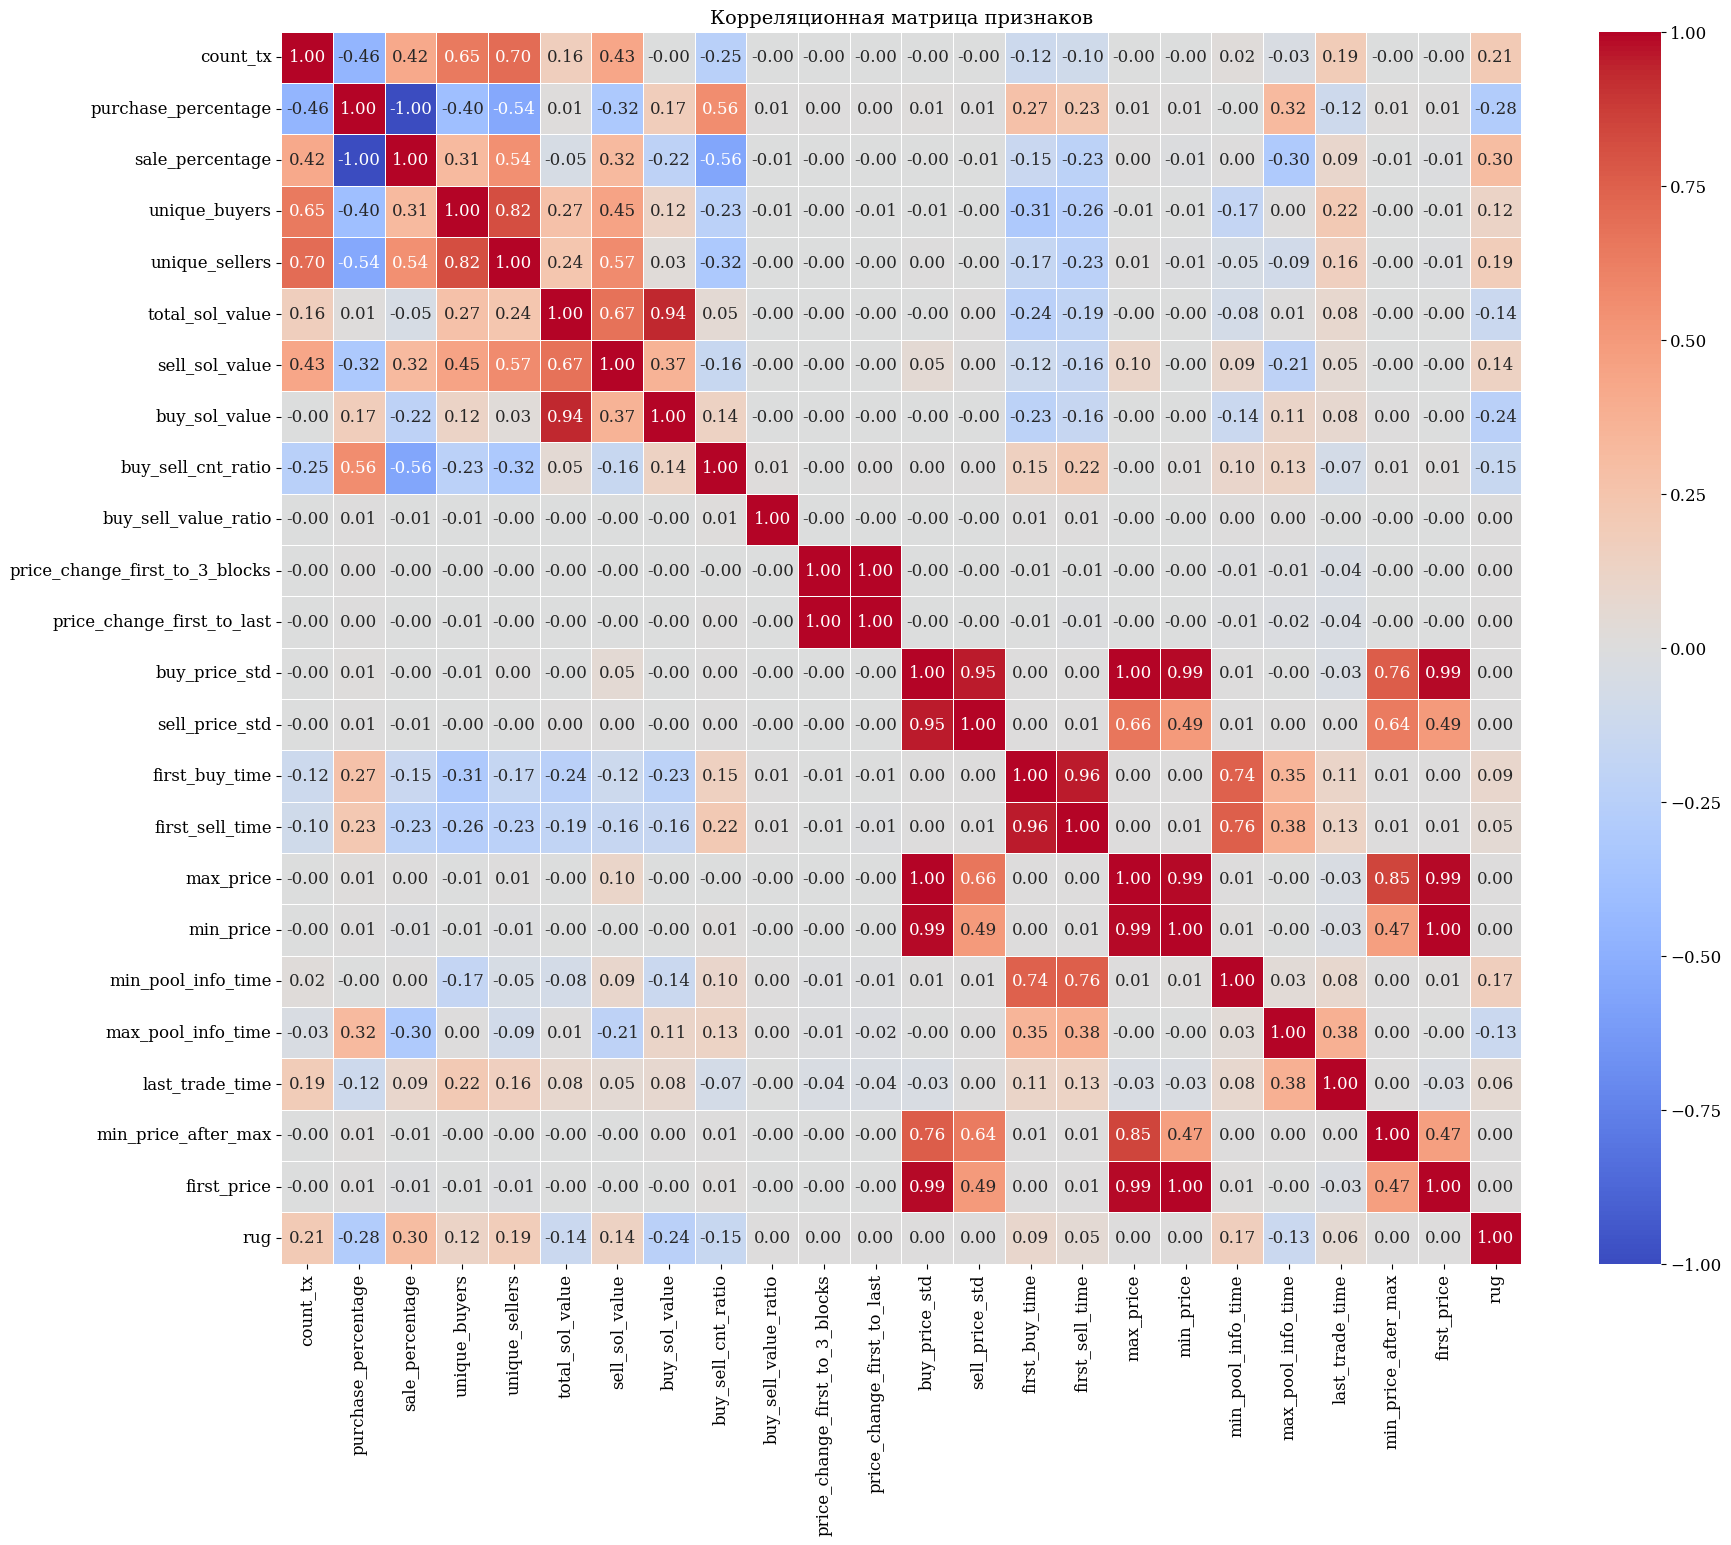

In [32]:
corr_features = [
    'count_tx',
    'purchase_percentage',
    'sale_percentage',
    'unique_buyers',
    'unique_sellers',
    'total_sol_value',
    'sell_sol_value',
    'buy_sol_value',
    'buy_sell_cnt_ratio',
    'buy_sell_value_ratio',
    'price_change_first_to_3_blocks',
    'price_change_first_to_last',
    'buy_price_std',
    'sell_price_std',
    'first_buy_time',
    'first_sell_time',
    'max_price',
    'min_price',
    'min_pool_info_time',
    'max_pool_info_time',
    'last_trade_time',
    'min_price_after_max',
    'first_price',
    'rug',
]

corr_matrix = train_raydium[corr_features].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица признаков')
plt.show()